In [4]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, Embedding, LSTM
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import pickle

# Configuration (Must match training exactly)
EMBEDDING_DIM = 256
UNITS = 512
VOCAB_SIZE = 5000
MAX_LENGTH = 35

# Load the saved tokenizer
with open('tokenizer.pkl', 'rb') as handle:
    tokenizer = pickle.load(handle)
print("Tokenizer loaded successfully!")

Tokenizer loaded successfully!


In [5]:
# 1. The Encoder
class ImageEncoder(tf.keras.Model):
    def __init__(self, embedding_dim):
        super(ImageEncoder, self).__init__()
        self.resnet = ResNet50(include_top=False, weights='imagenet')
        self.resnet.trainable = False
        self.fc = Dense(embedding_dim)

    def call(self, x):
        x = self.resnet(x)
        x = tf.reshape(x, (tf.shape(x)[0], -1, x.shape[3]))
        x = self.fc(x)
        x = tf.nn.relu(x)
        return x

# 2. The Attention Layer
class BahdanauAttention(tf.keras.layers.Layer):
    def __init__(self, units):
        super(BahdanauAttention, self).__init__()
        self.W1 = Dense(units)
        self.W2 = Dense(units)
        self.V = Dense(1)
    
    def call(self, query, values):
        query_with_time_axis = tf.expand_dims(query, 1)
        score = self.V(tf.nn.tanh(self.W1(query_with_time_axis) + self.W2(values)))
        attention_weights = tf.nn.softmax(score, axis=1)
        context_vector = attention_weights * values
        context_vector = tf.reduce_sum(context_vector, axis=1)
        return context_vector, attention_weights

# 3. The Decoder
class Decoder(tf.keras.Model):
    def __init__(self, vocab_size, embedding_dim, dec_units):
        super(Decoder, self).__init__()
        self.dec_units = dec_units
        self.embedding = Embedding(vocab_size, embedding_dim)
        self.lstm = LSTM(self.dec_units, return_sequences=True, return_state=True)
        self.fc = Dense(vocab_size)
        self.attention = BahdanauAttention(self.dec_units)

    def call(self, x, hidden, enc_output):
        context_vector, attention_weights = self.attention(hidden, enc_output)
        x = self.embedding(x)
        x = tf.concat([tf.expand_dims(context_vector, 1), x], axis=-1)
        output, state_h, state_c = self.lstm(x)
        output = tf.reshape(output, (-1, output.shape[2]))
        x = self.fc(output)
        return x, state_h, state_c, attention_weights

In [6]:
# Instantiate the models
encoder = ImageEncoder(EMBEDDING_DIM)
decoder = Decoder(VOCAB_SIZE, EMBEDDING_DIM, UNITS)

# Point to your checkpoints folder
checkpoint_path = "./checkpoints/train"
ckpt = tf.train.Checkpoint(encoder=encoder, decoder=decoder)
ckpt_manager = tf.train.CheckpointManager(ckpt, checkpoint_path, max_to_keep=5)

# Restore the weights!
if ckpt_manager.latest_checkpoint:
    ckpt.restore(ckpt_manager.latest_checkpoint).expect_partial()
    print("Model restored from checkpoint:", ckpt_manager.latest_checkpoint)
else:
    print("No checkpoint found. Check your file paths!")

I0000 00:00:1779788997.322576   32912 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3537 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Model restored from checkpoint: ./checkpoints/train/ckpt-23


In [7]:
def evaluate_and_plot(image_path):
    attention_plot = np.zeros((MAX_LENGTH, 49))

    # Preprocess image
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (224, 224))
    img_tensor = tf.keras.applications.resnet50.preprocess_input(img)
    img_tensor = tf.expand_dims(img_tensor, 0) 

    # Feature extraction
    features = encoder(img_tensor)
    hidden = tf.zeros((1, UNITS))
    dec_input = tf.expand_dims([tokenizer.word_index['<start>']], 0)
    
    result = []

    # Decoding loop
    for i in range(MAX_LENGTH):
        predictions, hidden, _, attention_weights = decoder(dec_input, hidden, features)
        attention_plot[i] = tf.reshape(attention_weights, (-1, )).numpy()
        
        predicted_id = tf.argmax(predictions[0]).numpy()
        word = tokenizer.index_word.get(predicted_id, '<unk>')
        
        if word == '<end>':
            break
            
        result.append(word)
        dec_input = tf.expand_dims([predicted_id], 0)

    attention_plot = attention_plot[:len(result), :]
    
    # --- PLOTTING ---
    fig = plt.figure(figsize=(15, 15))
    original_img = np.array(Image.open(image_path))
    
    for i in range(len(result)):
        temp_att = np.resize(attention_plot[i], (8, 8))
        ax = fig.add_subplot(len(result)//2 + 1, 2, i+1)
        ax.set_title(result[i], fontsize=18)
        
        img = ax.imshow(original_img)
        ax.imshow(temp_att, cmap='gray', alpha=0.6, extent=img.get_extent())
        ax.axis('off')
        
    plt.tight_layout()
    plt.show()
    
    print('Caption:', ' '.join(result))

I0000 00:00:1779789012.996534   32912 cuda_dnn.cc:461] Loaded cuDNN version 91001


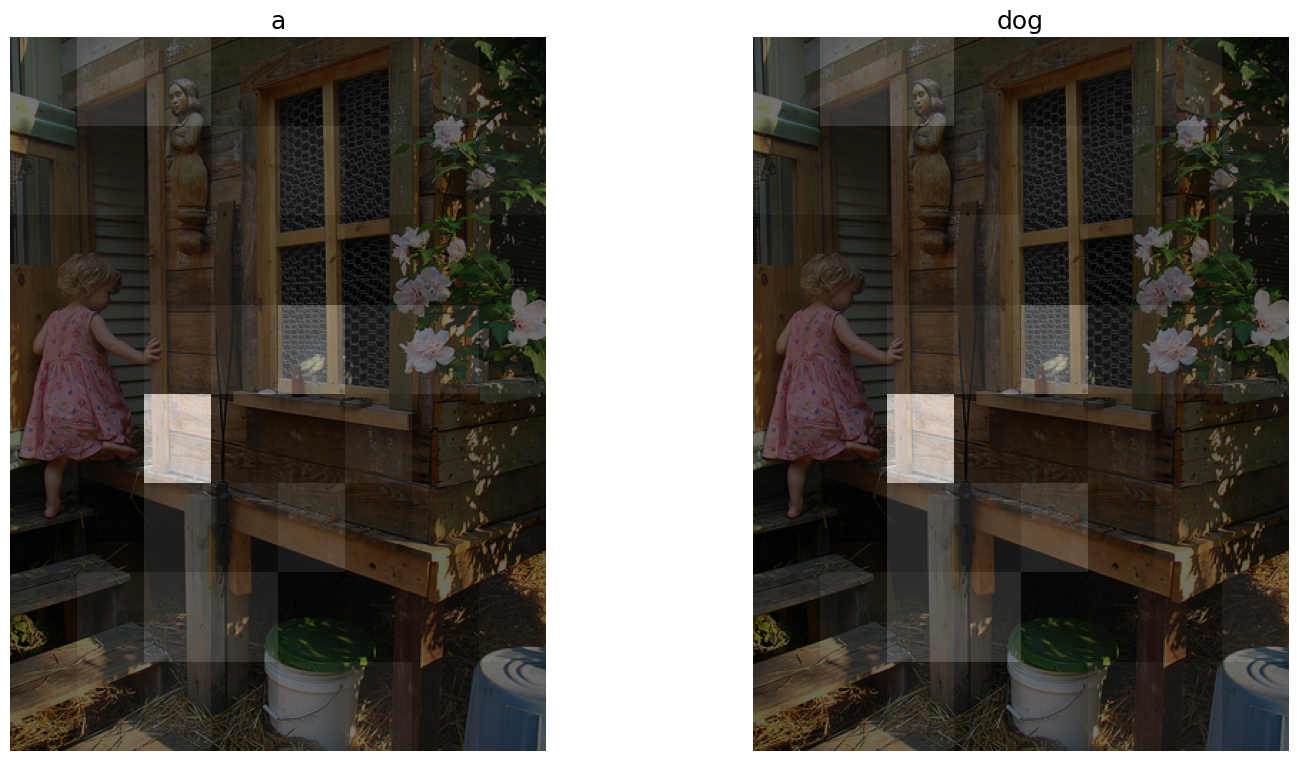

Caption: a dog


In [8]:
# Grab any image from your dataset (or download one from the web!)
test_image = "Images/1000268201_693b08cb0e.jpg" 
evaluate_and_plot(test_image)